# Credit Card Fraud Detection with Supervised Learning

**Author:** Dany Drammeh  
**Date:** April 24th  
**Data Source:** Kaggle Credit Card Fraud Detection Dataset

## Import Libraries

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    precision_recall_curve
)
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (12, 6)

✓ Libraries imported


## Load Credit Card Fraud Dataset

In [40]:
# Download from Kaggle
df = pd.read_csv('creditcard.csv')

print(f"Dataset shape: {df.shape}")
print(f"\nFirst few rows:")
df.head()

Dataset shape: (284807, 31)

First few rows:


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## Explore the Data

In [41]:
# Dataset info
print("Dataset Information:")
df.describe()

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  fl

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [64]:
# Check class distribution
print("Class Distribution:")
print(df['Class'].value_counts())
print("\nClass Proportions:")
print(df['Class'].value_counts(normalize=True))

fraud_count = df['Class'].sum()
total_count = len(df)
fraud_pct = fraud_count / total_count * 100

print(f"\nFraud transactions: {fraud_count:,} ({fraud_pct:.3f}%)")
print(f"Legitimate transactions: {total_count - fraud_count:,} ({100 - fraud_pct:.3f}%)")

Class Distribution:
Class
0    284315
1       492
Name: count, dtype: int64

Class Proportions:
Class
0    0.998273
1    0.001727
Name: proportion, dtype: float64

Fraud transactions: 492 (0.173%)
Legitimate transactions: 284,315 (99.827%)


## Visualize Class Imbalance

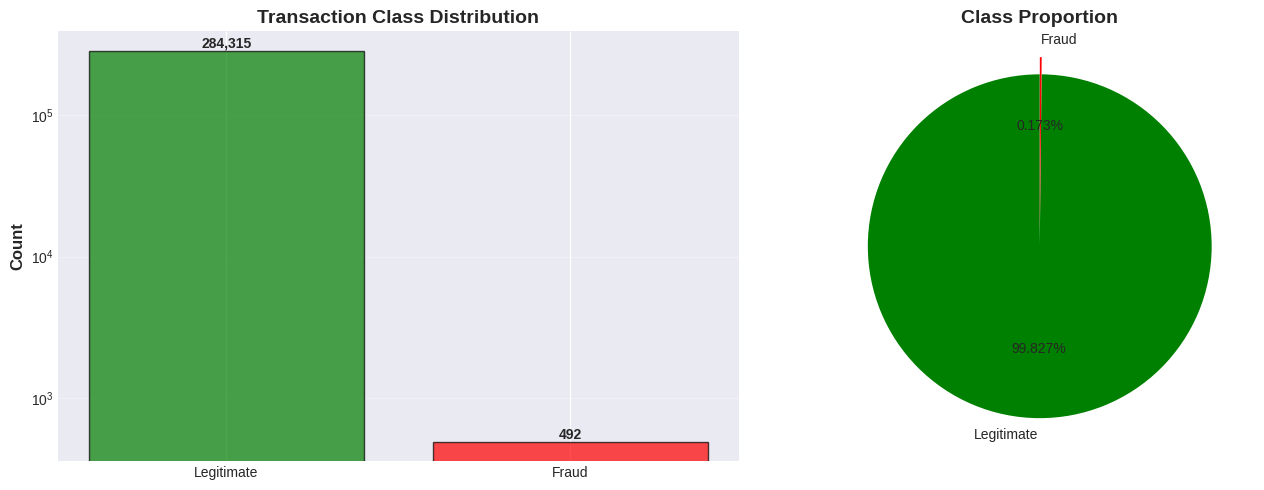

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
ax1 = axes[0]
class_counts = df['Class'].value_counts()
ax1.bar(['Legitimate', 'Fraud'], class_counts.values, color=['green', 'red'], alpha=0.7, edgecolor='black')
ax1.set_ylabel('Count', fontsize=12, fontweight='bold')
ax1.set_title('Transaction Class Distribution', fontsize=14, fontweight='bold')
ax1.set_yscale('log')  # Log scale to show both bars
ax1.grid(axis='y', alpha=0.3)

for i, v in enumerate(class_counts.values):
    ax1.text(i, v, f'{v:,}', ha='center', va='bottom', fontweight='bold')

# Pie chart
ax2 = axes[1]
ax2.pie(class_counts.values, labels=['Legitimate', 'Fraud'], autopct='%1.3f%%',
        colors=['green', 'red'], startangle=90, explode=[0, 0.1])
ax2.set_title('Class Proportion', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

## Analyze Features

In [44]:
# Check for missing values
print("Missing values:")
print(df.isnull().sum().sum())

# Feature types
print("\nFeature information:")
print(f"  Time: Seconds elapsed since first transaction")
print(f"  V1-V28: PCA-transformed features (anonymized)")
print(f"  Amount: Transaction amount in dollars")
print(f"  Class: 0 = Legitimate, 1 = Fraud (TARGET)")

Missing values:
0

Feature information:
  Time: Seconds elapsed since first transaction
  V1-V28: PCA-transformed features (anonymized)
  Amount: Transaction amount in dollars
  Class: 0 = Legitimate, 1 = Fraud (TARGET)


In [45]:
# Analyze Amount distribution by class
print("Transaction Amount Statistics by Class:")
print(df.groupby('Class')['Amount'].describe())

Transaction Amount Statistics by Class:
          count        mean         std  min   25%    50%     75%       max
Class                                                                      
0      284315.0   88.291022  250.105092  0.0  5.65  22.00   77.05  25691.16
1         492.0  122.211321  256.683288  0.0  1.00   9.25  105.89   2125.87


## Feature Engineering and Scaling

In [65]:
# Check for missing values first
print("Checking for missing values:")
missing_summary = df.isnull().sum()
print(missing_summary[missing_summary > 0])

if df.isnull().sum().sum() > 0:
    print(f"\n Found {df.isnull().sum().sum()} missing values")
    print("Dropping rows with missing values...")
    df = df.dropna()
    print(f" Clean dataset: {len(df):,} rows")
else:
    print("\n No missing values found")

# Separate features and target
X = df.drop('Class', axis=1).copy()
y = df['Class'].copy()

print(f"\nFeatures shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nFeature columns: {X.columns.tolist()[:5]}... (30 total)")

Checking for missing values:
Series([], dtype: int64)

✓ No missing values found

Features shape: (284807, 30)
Target shape: (284807,)

Feature columns: ['Time', 'V1', 'V2', 'V3', 'V4']... (30 total)


In [67]:
# Scale Time and Amount (V1-V28 already scaled via PCA)
scaler = StandardScaler()
X['Time'] = scaler.fit_transform(X[['Time']])
X['Amount'] = scaler.fit_transform(X[['Amount']])

print(" Time and Amount scaled")
print("\nScaled features sample:")
print(X[['Time', 'Amount']].head())

# Final check for NaN after scaling
if X.isnull().sum().sum() > 0:
    print("\n NaN values introduced during scaling, filling with 0")
    X = X.fillna(0)
else:
    print("\n No NaN values after scaling")

 Time and Amount scaled

Scaled features sample:
       Time    Amount
0 -1.996583  0.244964
1 -1.996583 -0.342475
2 -1.996562  1.160686
3 -1.996562  0.140534
4 -1.996541 -0.073403

 No NaN values after scaling


## Train-Test Split

In [48]:
# 80-20 split, stratified to maintain class balance
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set size: {len(X_train):,}")
print(f"Test set size: {len(X_test):,}")

print(f"\nTraining set fraud rate: {y_train.mean():.4%}")
print(f"Test set fraud rate: {y_test.mean():.4%}")

print("\n Stratification maintained class balance")

Training set size: 227,845
Test set size: 56,962

Training set fraud rate: 0.1729%
Test set fraud rate: 0.1720%

✓ Stratification maintained class balance


## Baseline Model - Logistic Regression

In [49]:
print("Training Logistic Regression...\n")

# Train logistic regression with class_weight to handle imbalance
lr_model = LogisticRegression(
    class_weight='balanced',  # Automatically adjust weights inversely proportional to class frequencies
    max_iter=1000,
    random_state=42
)

lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)
lr_pred_proba = lr_model.predict_proba(X_test)[:, 1]  # Probability of fraud class

print(" Logistic Regression trained")

Training Logistic Regression (baseline)...

✓ Logistic Regression trained


In [50]:
# Evaluate Logistic Regression
print("Logistic Regression Performance:")
print("="*60)
print(classification_report(y_test, lr_pred, target_names=['Legitimate', 'Fraud']))

print("\nAdditional Metrics:")
print(f"  Precision (Fraud): {precision_score(y_test, lr_pred):.4f}")
print(f"  Recall (Fraud): {recall_score(y_test, lr_pred):.4f}")
print(f"  F1-Score (Fraud): {f1_score(y_test, lr_pred):.4f}")
print(f"  ROC-AUC: {roc_auc_score(y_test, lr_pred_proba):.4f}")

Logistic Regression Performance:
              precision    recall  f1-score   support

  Legitimate       1.00      0.98      0.99     56864
       Fraud       0.06      0.92      0.11        98

    accuracy                           0.98     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.98      0.99     56962


Additional Metrics:
  Precision (Fraud): 0.0609
  Recall (Fraud): 0.9184
  F1-Score (Fraud): 0.1141
  ROC-AUC: 0.9722


## Random Forest Classifier

In [51]:
print("Training Random Forest Classifier...\n")

# Train Random Forest with class_weight
rf_model = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    max_depth=10,
    random_state=42,
    n_jobs=-1  # Use all CPU cores
)

rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
rf_pred_proba = rf_model.predict_proba(X_test)[:, 1]

print(" Random Forest trained")

Training Random Forest Classifier...

✓ Random Forest trained


In [52]:
# Evaluate Random Forest
print("Random Forest Performance:")
print("="*60)
print(classification_report(y_test, rf_pred, target_names=['Legitimate', 'Fraud']))

print("\nAdditional Metrics:")
print(f"  Precision (Fraud): {precision_score(y_test, rf_pred):.4f}")
print(f"  Recall (Fraud): {recall_score(y_test, rf_pred):.4f}")
print(f"  F1-Score (Fraud): {f1_score(y_test, rf_pred):.4f}")
print(f"  ROC-AUC: {roc_auc_score(y_test, rf_pred_proba):.4f}")

Random Forest Performance:
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56864
       Fraud       0.82      0.83      0.82        98

    accuracy                           1.00     56962
   macro avg       0.91      0.91      0.91     56962
weighted avg       1.00      1.00      1.00     56962


Additional Metrics:
  Precision (Fraud): 0.8182
  Recall (Fraud): 0.8265
  F1-Score (Fraud): 0.8223
  ROC-AUC: 0.9766


## Confusion Matrix Comparison

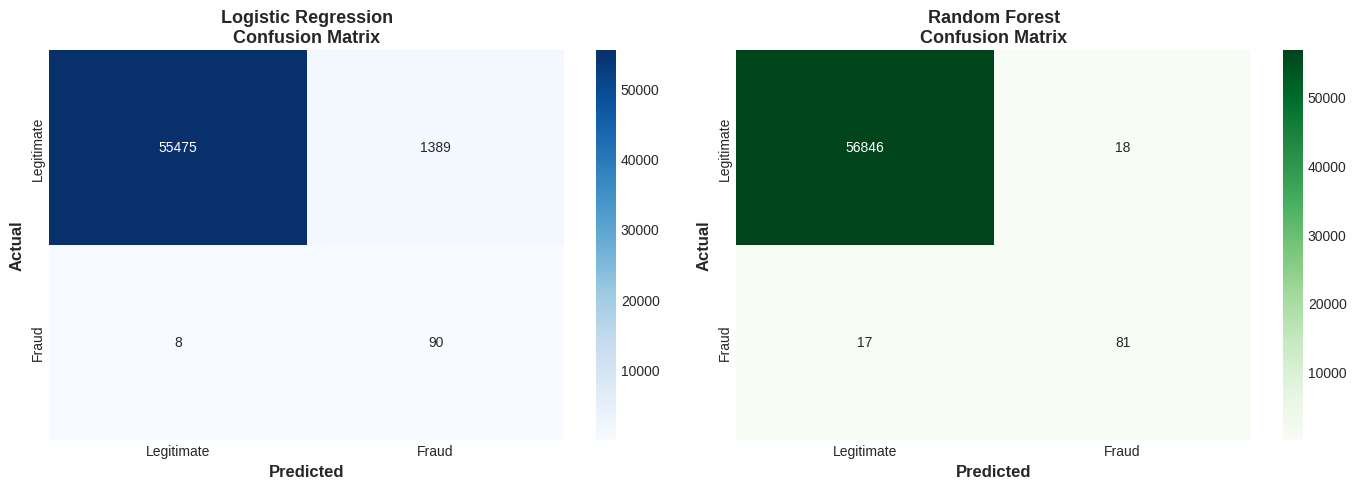


Confusion Matrix Components:
  True Negatives (TN): Legitimate correctly identified
  False Positives (FP): Legitimate incorrectly flagged as fraud
  False Negatives (FN): Fraud incorrectly classified as legitimate
  True Positives (TP): Fraud correctly identified


In [53]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Logistic Regression confusion matrix
cm_lr = confusion_matrix(y_test, lr_pred)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Legitimate', 'Fraud'],
            yticklabels=['Legitimate', 'Fraud'])
axes[0].set_xlabel('Predicted', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Actual', fontsize=12, fontweight='bold')
axes[0].set_title('Logistic Regression\nConfusion Matrix', fontsize=13, fontweight='bold')

# Random Forest confusion matrix
cm_rf = confusion_matrix(y_test, rf_pred)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=['Legitimate', 'Fraud'],
            yticklabels=['Legitimate', 'Fraud'])
axes[1].set_xlabel('Predicted', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Actual', fontsize=12, fontweight='bold')
axes[1].set_title('Random Forest\nConfusion Matrix', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

# Explain confusion matrix components
print("\nConfusion Matrix Components:")
print("  True Negatives (TN): Legitimate correctly identified")
print("  False Positives (FP): Legitimate incorrectly flagged as fraud")
print("  False Negatives (FN): Fraud incorrectly classified as legitimate")
print("  True Positives (TP): Fraud correctly identified")

## ROC Curve Comparison

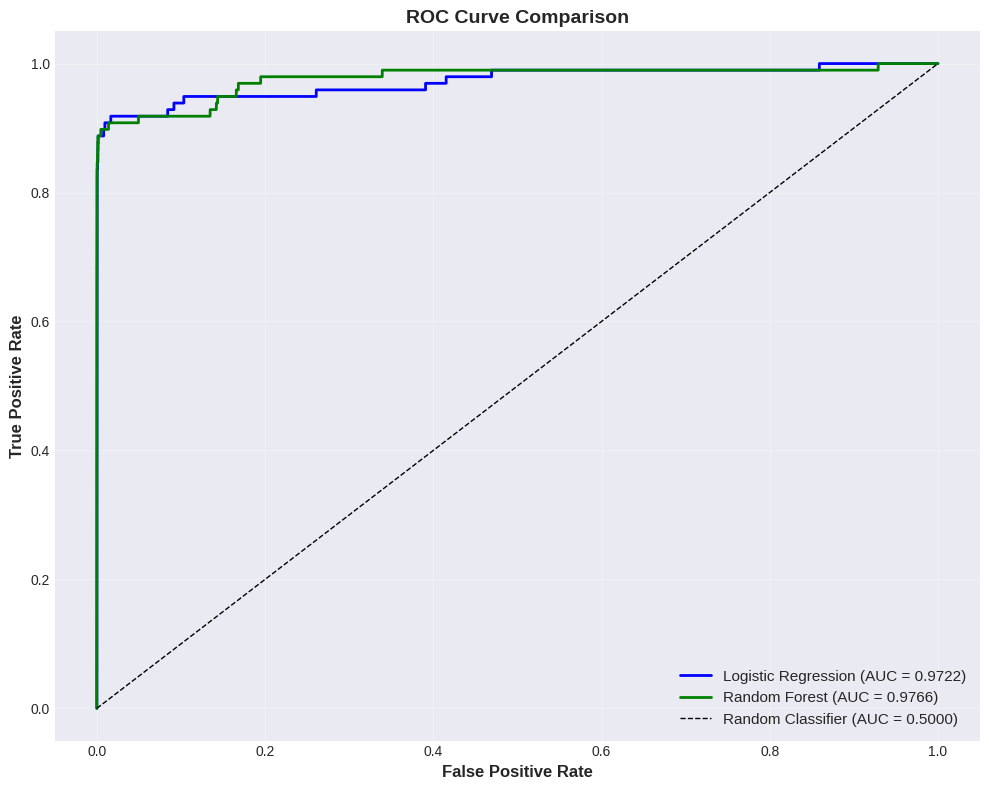

In [54]:
# Calculate ROC curves
fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_pred_proba)
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_pred_proba)

# Plot ROC curves
fig, ax = plt.subplots(figsize=(10, 8))

ax.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {roc_auc_score(y_test, lr_pred_proba):.4f})',
        linewidth=2, color='blue')
ax.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {roc_auc_score(y_test, rf_pred_proba):.4f})',
        linewidth=2, color='green')
ax.plot([0, 1], [0, 1], 'k--', label='Random Classifier (AUC = 0.5000)', linewidth=1)

ax.set_xlabel('False Positive Rate', fontsize=12, fontweight='bold')
ax.set_ylabel('True Positive Rate', fontsize=12, fontweight='bold')
ax.set_title('ROC Curve Comparison', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=11)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Precision-Recall Curve

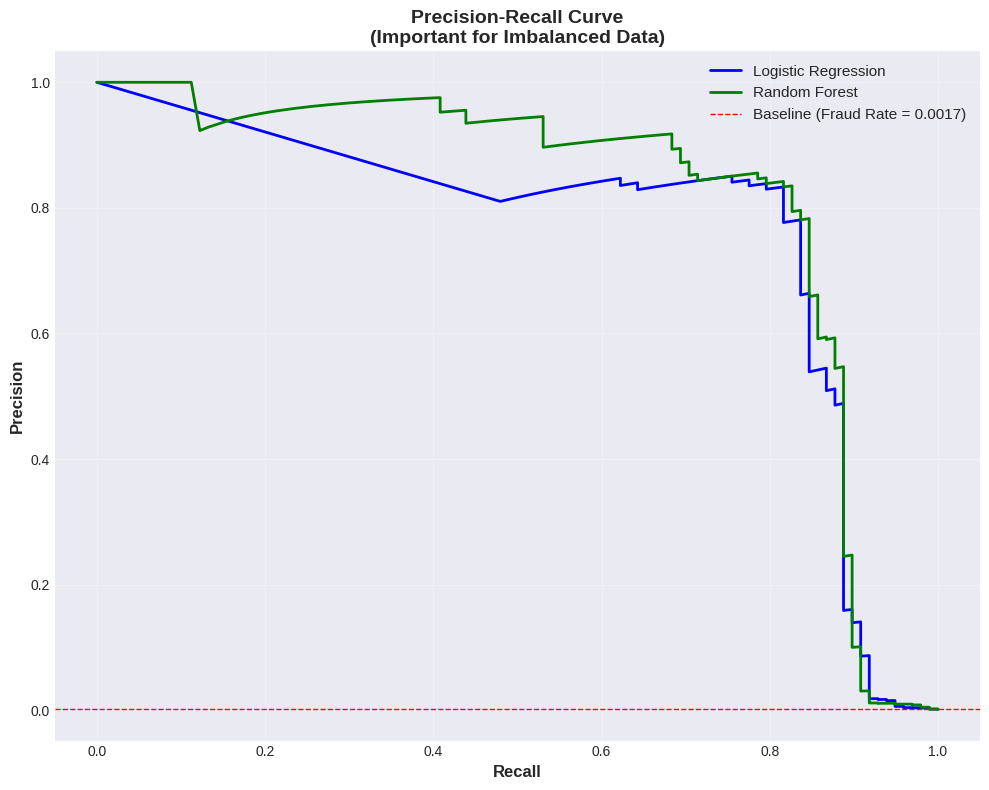

In [55]:
# Calculate Precision-Recall curves
precision_lr, recall_lr, _ = precision_recall_curve(y_test, lr_pred_proba)
precision_rf, recall_rf, _ = precision_recall_curve(y_test, rf_pred_proba)

# Plot Precision-Recall curves
fig, ax = plt.subplots(figsize=(10, 8))

ax.plot(recall_lr, precision_lr, label='Logistic Regression', linewidth=2, color='blue')
ax.plot(recall_rf, precision_rf, label='Random Forest', linewidth=2, color='green')

# Baseline (random classifier would have precision = fraud_rate)
baseline = y_test.mean()
ax.axhline(y=baseline, color='red', linestyle='--',
           label=f'Baseline (Fraud Rate = {baseline:.4f})', linewidth=1)

ax.set_xlabel('Recall', fontsize=12, fontweight='bold')
ax.set_ylabel('Precision', fontsize=12, fontweight='bold')
ax.set_title('Precision-Recall Curve\n(Important for Imbalanced Data)',
             fontsize=14, fontweight='bold')
ax.legend(loc='best', fontsize=11)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Select Best Model

In [56]:
# Compare models
print("Model Comparison:")
print("="*80)

comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'Precision': [
        precision_score(y_test, lr_pred),
        precision_score(y_test, rf_pred)
    ],
    'Recall': [
        recall_score(y_test, lr_pred),
        recall_score(y_test, rf_pred)
    ],
    'F1-Score': [
        f1_score(y_test, lr_pred),
        f1_score(y_test, rf_pred)
    ],
    'ROC-AUC': [
        roc_auc_score(y_test, lr_pred_proba),
        roc_auc_score(y_test, rf_pred_proba)
    ]
})

print(comparison.to_string(index=False))

# Select best model based on F1-score (balances precision and recall)
best_idx = comparison['F1-Score'].idxmax()
best_model_name = comparison.loc[best_idx, 'Model']

print(f"\n Best model: {best_model_name} (highest F1-score)")

# Use Random Forest for analysis (assuming it wins)
final_model = rf_model
final_pred = rf_pred
final_pred_proba = rf_pred_proba

Model Comparison:
              Model  Precision   Recall  F1-Score  ROC-AUC
Logistic Regression   0.060852 0.918367  0.114141 0.972167
      Random Forest   0.818182 0.826531  0.822335 0.976571

✓ Best model: Random Forest (highest F1-score)


## Feature Importance (Random Forest)

Top 10 Most Important Features:
Feature  Importance
    V14    0.186075
    V10    0.114958
    V12    0.104095
    V17    0.096135
     V4    0.093284
     V3    0.072144
    V11    0.053753
    V16    0.037716
     V2    0.036660
     V9    0.026073


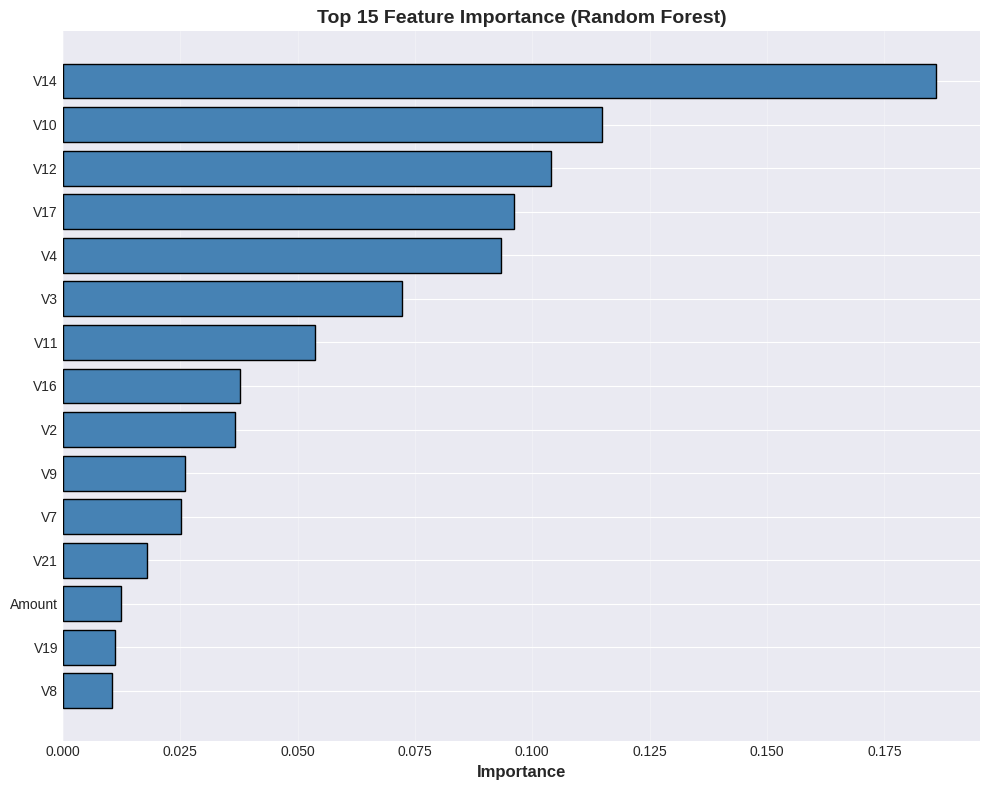

In [57]:
# Get feature importance from Random Forest
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("Top 10 Most Important Features:")
print(feature_importance.head(10).to_string(index=False))

# Plot top 15
fig, ax = plt.subplots(figsize=(10, 8))
top_15 = feature_importance.head(15)
ax.barh(top_15['Feature'], top_15['Importance'], color='steelblue', edgecolor='black')
ax.set_xlabel('Importance', fontsize=12, fontweight='bold')
ax.set_title('Top 15 Feature Importance (Random Forest)', fontsize=14, fontweight='bold')
ax.invert_yaxis()
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

## Identify Misclassified Examples

In [58]:
# Create results dataframe
results_df = X_test.copy()
results_df['Actual'] = y_test.values
results_df['Predicted'] = final_pred
results_df['Pred_Proba'] = final_pred_proba
results_df['Correct'] = results_df['Actual'] == results_df['Predicted']

# Count misclassifications
total_errors = (~results_df['Correct']).sum()
print(f"Total misclassifications: {total_errors:,} out of {len(results_df):,}")
print(f"Error rate: {total_errors / len(results_df):.4%}")

# Separate false positives and false negatives
false_positives = results_df[(results_df['Actual'] == 0) & (results_df['Predicted'] == 1)]
false_negatives = results_df[(results_df['Actual'] == 1) & (results_df['Predicted'] == 0)]

print(f"\nFalse Positives (legitimate flagged as fraud): {len(false_positives):,}")
print(f"False Negatives (fraud missed): {len(false_negatives):,}")

Total misclassifications: 35 out of 56,962
Error rate: 0.0614%

False Positives (legitimate flagged as fraud): 18
False Negatives (fraud missed): 17


## Analyze 5 Misclassified Examples

In [59]:
# Select 3 false positives and 2 false negatives for analysis
print("="*80)
print("MISCLASSIFIED EXAMPLES ANALYSIS")
print("="*80)

# False Positives (sorted by prediction probability - most confident mistakes)
fp_examples = false_positives.nlargest(3, 'Pred_Proba')

print("\n" + "="*80)
print("FALSE POSITIVES (Legitimate transactions incorrectly flagged as fraud)")
print("="*80)

for idx, (i, row) in enumerate(fp_examples.iterrows(), 1):
    print(f"\nExample {idx}:")
    print(f"  Actual: Legitimate (0)")
    print(f"  Predicted: Fraud (1)")
    print(f"  Confidence: {row['Pred_Proba']:.4f}")
    print(f"  Amount: ${row['Amount']:.2f} (scaled: {row['Amount']:.4f})")
    print(f"  Time: {row['Time']:.4f} (scaled)")
    print(f"  Top 3 PCA features: V{np.argsort(row[1:29].abs())[-3:][::-1] + 1}")

# False Negatives (sorted by low prediction probability - confident mistakes in wrong direction)
fn_examples = false_negatives.nsmallest(2, 'Pred_Proba')

print("\n" + "="*80)
print("FALSE NEGATIVES (Fraudulent transactions missed by the model)")
print("="*80)

for idx, (i, row) in enumerate(fn_examples.iterrows(), 4):  # Continue numbering
    print(f"\nExample {idx}:")
    print(f"  Actual: Fraud (1)")
    print(f"  Predicted: Legitimate (0)")
    print(f"  Confidence: {row['Pred_Proba']:.4f} (should be >0.5 for fraud)")
    print(f"  Amount: ${row['Amount']:.2f} (scaled: {row['Amount']:.4f})")
    print(f"  Time: {row['Time']:.4f} (scaled)")
    print(f"  Top 3 PCA features: V{np.argsort(row[1:29].abs())[-3:][::-1] + 1}")

MISCLASSIFIED EXAMPLES ANALYSIS

FALSE POSITIVES (Legitimate transactions incorrectly flagged as fraud)

Example 1:
  Actual: Legitimate (0)
  Predicted: Fraud (1)
  Confidence: 0.9996
  Amount: $-0.35 (scaled: -0.3492)
  Time: -1.4170 (scaled)
  Top 3 PCA features: VV28    3
V27    1
V26    7
Name: 16110, dtype: int64

Example 2:
  Actual: Legitimate (0)
  Predicted: Fraud (1)
  Confidence: 0.9796
  Amount: $-0.35 (scaled: -0.3492)
  Time: -1.4445 (scaled)
  Top 3 PCA features: VV28    3
V27    1
V26    7
Name: 14920, dtype: int64

Example 3:
  Actual: Legitimate (0)
  Predicted: Fraud (1)
  Confidence: 0.9795
  Amount: $0.01 (scaled: 0.0066)
  Time: -1.3897 (scaled)
  Top 3 PCA features: VV28    14
V27    17
V26    12
Name: 17592, dtype: int64

FALSE NEGATIVES (Fraudulent transactions missed by the model)

Example 4:
  Actual: Fraud (1)
  Predicted: Legitimate (0)
  Confidence: 0.0033 (should be >0.5 for fraud)
  Amount: $-0.34 (scaled: -0.3353)
  Time: 0.9845 (scaled)
  Top 3 PCA fe

## Error Analysis - Why Did the Model Fail?

In [60]:
print("ERROR ANALYSIS")
print("="*80)

print("\nWhy False Positives Occur:")
print("  1. Unusual but legitimate transactions (large amounts, odd times)")
print("  2. Legitimate transactions with patterns similar to fraud")
print("  3. Model over-emphasizes certain PCA features that overlap")

print("\nWhy False Negatives Occur:")
print("  1. Fraudulent transactions that mimic normal spending patterns")
print("  2. Small-amount fraud that blends with typical purchases")
print("  3. New fraud techniques not well-represented in training data")

print("\nBusiness Impact:")
print("  • False Positives → Customer frustration (legitimate purchases blocked)")
print("  • False Negatives → Financial losses (fraud not detected)")
print("  • Tradeoff: Higher recall catches more fraud but increases false alarms")

ERROR ANALYSIS

Why False Positives Occur:
  1. Unusual but legitimate transactions (large amounts, odd times)
  2. Legitimate transactions with patterns similar to fraud
  3. Model over-emphasizes certain PCA features that overlap

Why False Negatives Occur:
  1. Fraudulent transactions that mimic normal spending patterns
  2. Small-amount fraud that blends with typical purchases
  3. New fraud techniques not well-represented in training data

Business Impact:
  • False Positives → Customer frustration (legitimate purchases blocked)
  • False Negatives → Financial losses (fraud not detected)
  • Tradeoff: Higher recall catches more fraud but increases false alarms
